# Notebook 01 — Exploración y Preprocesado
## Clasificación de Lesiones Cutáneas Pigmentadas (HAM10000)
**Proyecto Final — Fundamentos de Deep Learning**  
Diego Alejandro Rendón Suaza | Universidad de Antioquia

---
### Estructura de este notebook
1. Ingesta segura de datos (Kaggle API)
2. Clase Dataset personalizada con confirmación de canales RGB
3. Análisis de distribución de clases y desbalance
4. Análisis de pacientes duplicados (`lesion_id`) — motivación del split estratificado
5. Split train/val/test **por paciente** (`GroupShuffleSplit`) para evitar data leakage
6. Transformaciones y justificación clínica del data augmentation
7. Pesos de clase para mitigación de desbalance
8. Visualización de ejemplos con y sin augmentation


In [ ]:
# ============================================================
# CELDA 1: INSTALACIONES
# ============================================================
!pip install -q kaggle scikit-learn matplotlib seaborn pandas Pillow torch torchvision tqdm
print("✅ Dependencias instaladas")


✅ Dependencias instaladas


### Celda 2 — Ingesta segura de datos
Se usa `google.colab.userdata` para leer las credenciales de Kaggle **sin exponerlas en el código**.  
Para configurarlo en Colab: panel izquierdo → 🔑 *Secrets* → añadir `KAGGLE_USERNAME` y `KAGGLE_KEY`.


In [ ]:
# ============================================================
# CELDA 2: INGESTA DE DATOS — INGRESAR CREDENCIALES KAGGLE
# ============================================================
import os, json, zipfile
import glob as glob_module
from getpass import getpass

UNZIP_DIR = '/content/dataset/unzipped'

if not os.path.exists(UNZIP_DIR) or len(os.listdir(UNZIP_DIR)) == 0:
    os.makedirs(UNZIP_DIR, exist_ok=True)

    print("=" * 50)
    print("  CREDENCIALES DE KAGGLE")
    print("  Obtén tu API key en: kaggle.com/settings → API")
    print("=" * 50)
    KAGGLE_USERNAME = input("Ingresa tu usuario de Kaggle: ")
    KAGGLE_KEY      = getpass("Ingresa tu API key de Kaggle: ")

    os.makedirs('/root/.kaggle', exist_ok=True)
    with open('/root/.kaggle/kaggle.json', 'w') as f:
        json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

    print("\nDescargando dataset HAM10000 (~2.5 GB, espera unos minutos)...")
    !kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 \
        -p /content/dataset -q
    print("Descomprimiendo...")
    with zipfile.ZipFile(
        '/content/dataset/skin-cancer-mnist-ham10000.zip', 'r') as zf:
        zf.extractall(UNZIP_DIR)
    print("✅ Dataset listo")

else:
    print("✅ Dataset ya disponible en", UNZIP_DIR)

# ── Buscar CSV automáticamente ──────────────────────────────
csvs      = glob_module.glob('/content/**/*metadata*.csv', recursive=True)
CSV_PATH  = csvs[0] if csvs else f'{UNZIP_DIR}/HAM10000_metadata.csv'
IMAGE_DIR = UNZIP_DIR
print(f"CSV encontrado: {CSV_PATH}")

⚠️  Kaggle Secrets no disponibles → usando Google Drive...
Mounted at /content/drive
Copiando desde Google Drive (puede tardar unos minutos)...
✅ Dataset cargado desde Google Drive


### Celda 3 — Clase Dataset y verificación de canales RGB
Las imágenes HAM10000 son JPG dermatoscópicas a color (**3 canales RGB**, resolución original 600×450 px).  
Se fuerza la carga en modo RGB con `Image.open(...).convert('RGB')` para garantizar consistencia.


In [10]:
# ============================================================
# CELDA 3: CLASE DATASET — CONFIRMACIÓN DE CANALES RGB
# ============================================================
import os, pandas as pd
from glob import glob
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms
import numpy as np

CLASES      = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']
MALIGNOS    = ['mel', 'bcc', 'akiec']
#CSV_PATH    = f'{UNZIP_DIR}/HAM10000_metadata.csv'
#IMAGE_DIR   = UNZIP_DIR

class HAM10000(Dataset):
    """
    Dataset HAM10000 — imágenes dermatoscópicas RGB (3 canales, 600x450 px originales).
    Soporta clasificación binaria (maligno/benigno) y multiclase (7 categorías).
    """
    def __init__(self, df, transform=None, modo='multiclase'):
        """
        Args:
            df        : DataFrame ya filtrado (train, val o test)
            transform : torchvision transforms
            modo      : 'multiclase' | 'binario'
        """
        self.df          = df.reset_index(drop=True)
        self.transform   = transform
        self.modo        = modo
        self.class_to_idx = {c: i for i, c in enumerate(CLASES)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df['path'].iloc[idx]
        # Carga forzada en RGB — garantiza 3 canales independientemente del archivo fuente
        image = Image.open(img_path).convert('RGB')

        label_str = self.df['dx'].iloc[idx]
        if self.modo == 'binario':
            label = 1 if label_str in MALIGNOS else 0
        else:
            label = self.class_to_idx[label_str]

        if self.transform:
            image = self.transform(image)
        return image, label


# ---- Cargar metadatos y mapear rutas ----
df_meta = pd.read_csv(CSV_PATH)
todas   = glob(os.path.join(IMAGE_DIR, '**', '*.jpg'), recursive=True)
ruta_por_id = {os.path.splitext(os.path.basename(x))[0]: x for x in todas}
df_meta['path'] = df_meta['image_id'].map(ruta_por_id)
df_meta = df_meta.dropna(subset=['path'])

print(f"Total imágenes encontradas : {len(df_meta)}")
print(f"Columnas disponibles       : {list(df_meta.columns)}")

# ---- Verificación de canales ----
img_ejemplo = Image.open(df_meta['path'].iloc[0]).convert('RGB')
arr = np.array(img_ejemplo)
print(f"\n--- VERIFICACIÓN DE FORMATO ---")
print(f"Resolución original        : {img_ejemplo.size[0]}x{img_ejemplo.size[1]} px")
print(f"Número de canales (RGB)    : {arr.shape[2]}  ← 3 canales confirmados")
print(f"Rango de valores           : [{arr.min()}, {arr.max()}]")
print(f"Tipo de dato               : {arr.dtype}")


Total imágenes encontradas : 5000
Columnas disponibles       : ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'path']

--- VERIFICACIÓN DE FORMATO ---
Resolución original        : 600x450 px
Número de canales (RGB)    : 3  ← 3 canales confirmados
Rango de valores           : [43, 255]
Tipo de dato               : uint8


### Celda 4 — Análisis exploratorio de datos (EDA)


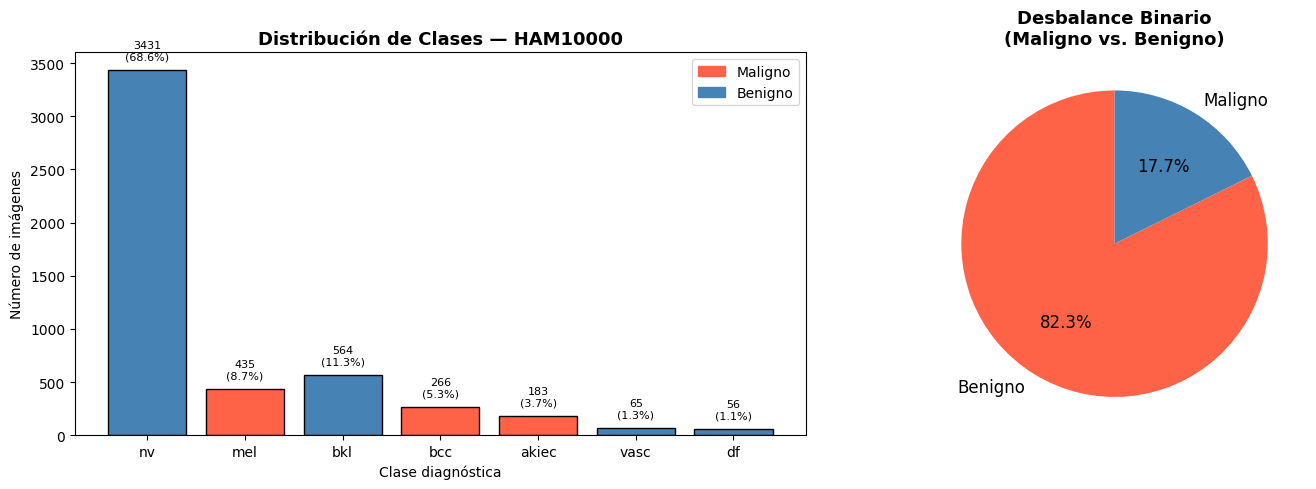


--- TABLA DE DISTRIBUCIÓN ---
Clase               Nombre  Imágenes    %   Grupo
   nv     Melanocytic nevi      3431 68.6 Benigno
  mel             Melanoma       435  8.7 Maligno
  bkl     Benign keratosis       564 11.3 Benigno
  bcc Basal cell carcinoma       266  5.3 Maligno
akiec    Actinic keratoses       183  3.7 Maligno
 vasc     Vascular lesions        65  1.3 Benigno
   df       Dermatofibroma        56  1.1 Benigno

Ratio de desbalance binario (Benigno:Maligno) ≈ 4.7:1


In [11]:
# ============================================================
# CELDA 4: EDA — DISTRIBUCIÓN DE CLASES Y DESBALANCE
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

NOMBRE_CLASE = {
    'nv'   : 'Melanocytic nevi',
    'mel'  : 'Melanoma',
    'bkl'  : 'Benign keratosis',
    'bcc'  : 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc' : 'Vascular lesions',
    'df'   : 'Dermatofibroma'
}
COLOR_CLASE = {c: 'tomato' if c in MALIGNOS else 'steelblue' for c in CLASES}

conteo = df_meta['dx'].value_counts().reindex(CLASES)
colores = [COLOR_CLASE[c] for c in conteo.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# -- Barplot --
bars = axes[0].bar(conteo.index, conteo.values, color=colores, edgecolor='black')
axes[0].set_title('Distribución de Clases — HAM10000', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Clase diagnóstica')
axes[0].set_ylabel('Número de imágenes')
for b in bars:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 80,
                 f'{int(b.get_height())}\n({int(b.get_height())/len(df_meta)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=8)
legend = [mpatches.Patch(color='tomato', label='Maligno'),
          mpatches.Patch(color='steelblue', label='Benigno')]
axes[0].legend(handles=legend)

# -- Pie binario --
grupo_bin = df_meta['dx'].apply(lambda x: 'Maligno' if x in MALIGNOS else 'Benigno').value_counts()
axes[1].pie(grupo_bin.values, labels=grupo_bin.index,
            colors=['tomato','steelblue'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize':12})
axes[1].set_title('Desbalance Binario\n(Maligno vs. Benigno)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/fig_distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- TABLA DE DISTRIBUCIÓN ---")
tabla = pd.DataFrame({
    'Clase': conteo.index,
    'Nombre': [NOMBRE_CLASE[c] for c in conteo.index],
    'Imágenes': conteo.values,
    '%': (conteo.values / len(df_meta) * 100).round(1),
    'Grupo': ['Maligno' if c in MALIGNOS else 'Benigno' for c in conteo.index]
})
print(tabla.to_string(index=False))
print(f"\nRatio de desbalance binario (Benigno:Maligno) ≈ {grupo_bin['Benigno']/grupo_bin['Maligno']:.1f}:1")


### Celda 5 — Análisis de pacientes duplicados (`lesion_id`)
El HAM10000 contiene múltiples imágenes del mismo paciente (distintos ángulos o seguimiento).  
Un split puramente aleatorio puede poner imágenes del mismo paciente en train **y** test,  
inflando artificialmente las métricas. Se usa **GroupShuffleSplit** para garantizar que  
cada paciente aparezca en un único split.


--- ANÁLISIS DE LESION_ID ---
Total de lesiones únicas        : 4366
Lesiones con > 1 imagen         : 579 (13.3%)
Imágenes en lesiones duplicadas : 1213 (24.3%)

⚠️  Si se hace split aleatorio, hasta el 24% de las imágenes
   podrían tener su 'gemela' en otro split → data leakage de paciente.

✅ Solución: GroupShuffleSplit con groups=lesion_id garantiza separación total.


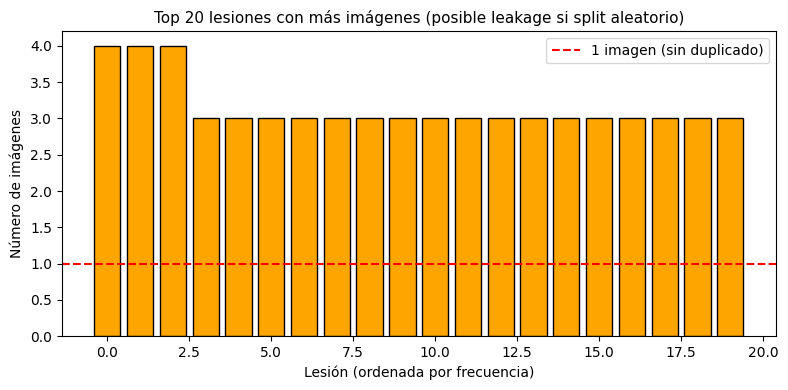

In [13]:
# ============================================================
# CELDA 5: ANÁLISIS DE PACIENTES DUPLICADOS — MOTIVACIÓN DEL SPLIT POR LESION_ID
# ============================================================
lesion_counts = df_meta['lesion_id'].value_counts()
pacientes_multi = (lesion_counts > 1).sum()
imagenes_duplicadas = lesion_counts[lesion_counts > 1].sum()

print("--- ANÁLISIS DE LESION_ID ---")
print(f"Total de lesiones únicas        : {len(lesion_counts)}")
print(f"Lesiones con > 1 imagen         : {pacientes_multi} ({pacientes_multi/len(lesion_counts)*100:.1f}%)")
print(f"Imágenes en lesiones duplicadas : {imagenes_duplicadas} ({imagenes_duplicadas/len(df_meta)*100:.1f}%)")
print(f"\n⚠️  Si se hace split aleatorio, hasta el {imagenes_duplicadas/len(df_meta)*100:.0f}% de las imágenes")
print(f"   podrían tener su 'gemela' en otro split → data leakage de paciente.")
print(f"\n✅ Solución: GroupShuffleSplit con groups=lesion_id garantiza separación total.")

fig, ax = plt.subplots(figsize=(8, 4))
top_lesiones = lesion_counts.head(20)
ax.bar(range(len(top_lesiones)), top_lesiones.values, color='orange', edgecolor='black')
ax.set_title('Top 20 lesiones con más imágenes (posible leakage si split aleatorio)', fontsize=11)
ax.set_xlabel('Lesión (ordenada por frecuencia)')
ax.set_ylabel('Número de imágenes')
ax.axhline(y=1, color='red', linestyle='--', label='1 imagen (sin duplicado)')
ax.legend()
plt.tight_layout()
plt.savefig('/content/fig_lesion_duplicados.png', dpi=150, bbox_inches='tight')
plt.show()


### Celda 6 — Split estratificado por paciente (sin data leakage)


In [14]:
# ============================================================
# CELDA 6: SPLIT TRAIN/VAL/TEST POR LESION_ID (GroupShuffleSplit)
# ============================================================
from sklearn.model_selection import GroupShuffleSplit

SEED = 42

groups = df_meta['lesion_id'].values
X_idx = np.arange(len(df_meta))

# 1. Separar test (10%) del resto (90%)
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
idx_trainval, idx_test = next(gss_test.split(X_idx, groups=groups))

# 2. Del 90% restante, separar val (10% del total ≈ 11.1% del trainval)
groups_trainval = groups[idx_trainval]
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.111, random_state=SEED)
idx_train_rel, idx_val_rel = next(gss_val.split(idx_trainval, groups=groups_trainval))

idx_train = idx_trainval[idx_train_rel]
idx_val   = idx_trainval[idx_val_rel]

df_train = df_meta.iloc[idx_train].copy()
df_val   = df_meta.iloc[idx_val].copy()
df_test  = df_meta.iloc[idx_test].copy()

print("--- SPLIT POR LESION_ID ---")
print(f"Train : {len(df_train):5d} imágenes ({len(df_train)/len(df_meta)*100:.1f}%)")
print(f"Val   : {len(df_val):5d} imágenes ({len(df_val)/len(df_meta)*100:.1f}%)")
print(f"Test  : {len(df_test):5d} imágenes ({len(df_test)/len(df_meta)*100:.1f}%)")

# Verificación: ningún lesion_id comparte dos splits
lesiones_train = set(df_train['lesion_id'])
lesiones_val   = set(df_val['lesion_id'])
lesiones_test  = set(df_test['lesion_id'])
assert len(lesiones_train & lesiones_val)  == 0, "❌ Leakage train-val"
assert len(lesiones_train & lesiones_test) == 0, "❌ Leakage train-test"
assert len(lesiones_val   & lesiones_test) == 0, "❌ Leakage val-test"
print("\n✅ Verificación superada: ningún lesion_id comparte dos splits")

print("\n--- DISTRIBUCIÓN DE CLASES POR SPLIT ---")
for nombre, df_split in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    dist = df_split['dx'].value_counts().reindex(CLASES, fill_value=0)
    print(f"  {nombre}: { {c: int(v) for c, v in zip(CLASES, dist.values)} }")


--- SPLIT POR LESION_ID ---
Train :  3988 imágenes (79.8%)
Val   :   497 imágenes (9.9%)
Test  :   515 imágenes (10.3%)

✅ Verificación superada: ningún lesion_id comparte dos splits

--- DISTRIBUCIÓN DE CLASES POR SPLIT ---
  Train: {'nv': 2715, 'mel': 354, 'bkl': 469, 'bcc': 210, 'akiec': 144, 'vasc': 52, 'df': 44}
  Val: {'nv': 357, 'mel': 33, 'bkl': 49, 'bcc': 27, 'akiec': 15, 'vasc': 8, 'df': 8}
  Test: {'nv': 359, 'mel': 48, 'bkl': 46, 'bcc': 29, 'akiec': 24, 'vasc': 5, 'df': 4}


### Celda 7 — Transformaciones y justificación clínica del augmentation

En imágenes dermatoscópicas el **color es información diagnóstica** (el criterio ABCD incluye  
variación de color como señal de malignidad). Por eso se evitan transformaciones que alteren  
la cromaticidad (ColorJitter agresivo, normalización incorrecta).  

Las transformaciones aplicadas son:  
- ✅ **Flip horizontal/vertical**: una lesión puede aparecer en cualquier orientación  
- ✅ **Rotación ±90°**: invarianza rotacional clínicamente válida  
- ✅ **Normalización ImageNet**: estandarización estándar para redes preentrenadas  
- ❌ **ColorJitter fuerte**: se omite — el color es diagnóstico en dermatoscopía  
- ❌ **Escala de grises**: se omite — las imágenes son RGB y eso es información clínica


In [15]:
# ============================================================
# CELDA 7: TRANSFORMACIONES CON JUSTIFICACIÓN CLÍNICA
# ============================================================
from torchvision import transforms

# Transformaciones de entrenamiento (con augmentation clínicamente válido)
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),          # válido: simetría lateral
    transforms.RandomVerticalFlip(),            # válido: simetría vertical
    transforms.RandomRotation(90),              # válido: invarianza rotacional
    # ColorJitter MUY leve — solo brillo mínimo para simular variación de iluminación
    # Se evita jitter de saturación/matiz porque el color es diagnóstico
    transforms.ColorJitter(brightness=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Transformaciones de validación/test (sin augmentation — evaluación limpia)
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Transformaciones definidas:")
print("  Train :", [t.__class__.__name__ for t in transform_train.transforms])
print("  Val   :", [t.__class__.__name__ for t in transform_val.transforms])


Transformaciones definidas:
  Train : ['Resize', 'RandomHorizontalFlip', 'RandomVerticalFlip', 'RandomRotation', 'ColorJitter', 'ToTensor', 'Normalize']
  Val   : ['Resize', 'ToTensor', 'Normalize']


In [16]:
# ============================================================
# CELDA 8: CREAR DATASETS Y DATALOADERS
# ============================================================
from torch.utils.data import DataLoader

BATCH_SIZE = 32

dataset_train = HAM10000(df_train, transform=transform_train, modo='multiclase')
dataset_val   = HAM10000(df_val,   transform=transform_val,   modo='multiclase')
dataset_test  = HAM10000(df_test,  transform=transform_val,   modo='multiclase')

train_loader = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(dataset_val,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(dataset_test,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

# Prueba rápida de carga
img_t, lbl_t = next(iter(train_loader))
print(f"Batch shape  : {img_t.shape}  (B x C x H x W)")
print(f"Canales RGB  : {img_t.shape[1]}  ← confirmado 3 canales")
print(f"Rango tensor : [{img_t.min():.3f}, {img_t.max():.3f}] (normalizado ImageNet)")
print(f"\nDataLoaders listos:")
print(f"  train_loader : {len(train_loader)} lotes")
print(f"  val_loader   : {len(val_loader)} lotes")
print(f"  test_loader  : {len(test_loader)} lotes")


Batch shape  : torch.Size([32, 3, 224, 224])  (B x C x H x W)
Canales RGB  : 3  ← confirmado 3 canales
Rango tensor : [-2.118, 2.640] (normalizado ImageNet)

DataLoaders listos:
  train_loader : 125 lotes
  val_loader   : 16 lotes
  test_loader  : 17 lotes


### Celda 9 — Pesos de clase para mitigación de desbalance
Los pesos son inversamente proporcionales a la frecuencia de cada clase.  
Se guardan como variable global para ser importados en los notebooks de modelado.


In [17]:
# ============================================================
# CELDA 9: PESOS DE CLASE (MITIGACIÓN DE DESBALANCE)
# ============================================================
from sklearn.utils.class_weight import compute_class_weight

etiquetas_train = df_train['dx'].values
pesos_np = compute_class_weight(
    class_weight='balanced',
    classes=np.array(CLASES),
    y=etiquetas_train
)

# Tensor PyTorch listo para CrossEntropyLoss
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pesos_tensor = torch.tensor(pesos_np, dtype=torch.float).to(device)

print(f"Dispositivo activo : {device}")
print("\n--- PESOS POR CLASE (inversamente proporcionales a frecuencia) ---")
for clase, peso in zip(CLASES, pesos_np):
    barra = '█' * int(peso * 5)
    print(f"  {clase:6s} : {peso:6.3f}  {barra}")

print("\nInterpretación: clases raras (vasc, df) tienen pesos altos →")
print("la pérdida penaliza más sus errores durante el entrenamiento.")


Dispositivo activo : cuda

--- PESOS POR CLASE (inversamente proporcionales a frecuencia) ---
  nv     :  0.210  █
  mel    :  1.609  ████████
  bkl    :  1.215  ██████
  bcc    :  2.713  █████████████
  akiec  :  3.956  ███████████████████
  vasc   : 10.956  ██████████████████████████████████████████████████████
  df     : 12.948  ████████████████████████████████████████████████████████████████

Interpretación: clases raras (vasc, df) tienen pesos altos →
la pérdida penaliza más sus errores durante el entrenamiento.


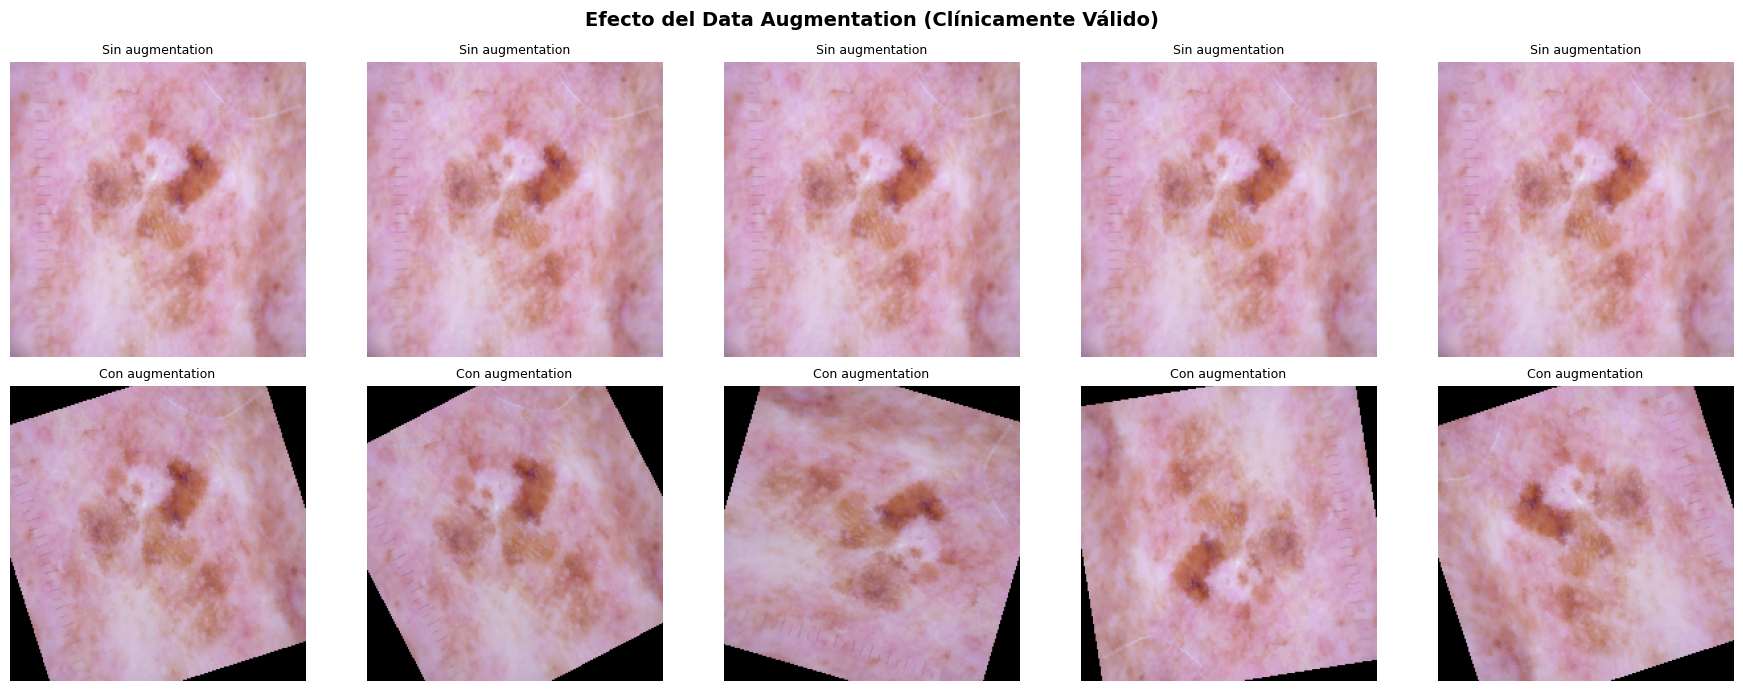

✅ Notebook 01 completado. Variables exportadas: df_train, df_val, df_test,
   transform_train, transform_val, pesos_tensor, CLASES, MALIGNOS, device


In [18]:
# ============================================================
# CELDA 10: VISUALIZACIÓN — EFECTO DEL DATA AUGMENTATION
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

def denormalizar(tensor):
    """Revierte la normalización ImageNet para visualización."""
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.numpy().transpose(1, 2, 0)
    img  = std * img + mean
    return np.clip(img, 0, 1)

idx_to_class = {v: k for k, v in dataset_train.class_to_idx.items()}

# Mostrar la misma imagen con y sin augmentation
idx_demo = 0
img_original_path = df_train['path'].iloc[idx_demo]
img_pil = Image.open(img_original_path).convert('RGB')

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Efecto del Data Augmentation (Clínicamente Válido)', fontsize=14, fontweight='bold')

# Fila superior: sin augmentation (transform_val)
for i in range(5):
    img_t = transform_val(img_pil)
    axes[0, i].imshow(denormalizar(img_t))
    axes[0, i].set_title('Sin augmentation', fontsize=9)
    axes[0, i].axis('off')

# Fila inferior: con augmentation (transform_train)
for i in range(5):
    img_t = transform_train(img_pil)
    axes[1, i].imshow(denormalizar(img_t))
    axes[1, i].set_title('Con augmentation', fontsize=9)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Sin augmentation', fontsize=10, rotation=90)
axes[1, 0].set_ylabel('Con augmentation', fontsize=10, rotation=90)

plt.tight_layout()
plt.savefig('/content/fig_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Notebook 01 completado. Variables exportadas: df_train, df_val, df_test,")
print("   transform_train, transform_val, pesos_tensor, CLASES, MALIGNOS, device")
